In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('cardiovascular_risk_dataset.csv')
df

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [2]:
df = df.drop(columns=['Patient_ID'], axis=1)
df['smoking_status'] = df['smoking_status'].map({'Former': 2, 'Current': 1, 'Never': 0}).astype(float)
df['risk_category'] = df['risk_category'].map({'High': 2, 'Medium': 1, 'Low': 0}).astype(float)
df['family_history_heart_disease'] = df['family_history_heart_disease'].map({'Yes': 1, 'No': 0}).astype(float)
df

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,62,25.0,142,93,247,72,0.0,11565,3,5.6,8.2,0.0,7,0.7,28.1,1.0
1,54,29.7,158,101,254,74,1.0,4036,8,0.5,6.7,0.0,5,4.5,63.0,2.0
2,46,36.2,170,113,276,80,1.0,3043,9,0.4,4.0,0.0,1,20.8,73.1,2.0
3,48,30.4,153,98,230,73,2.0,5604,5,0.6,8.0,0.0,4,8.5,39.5,1.0
4,46,25.3,139,87,206,69,1.0,7464,1,2.0,6.1,0.0,5,3.6,29.3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,0.0,6724,3,2.9,7.2,0.0,7,0.0,0.0,0.0
5496,18,30.9,128,82,235,75,0.0,3661,4,0.0,5.5,0.0,1,9.6,16.8,0.0
5497,63,29.5,142,92,239,69,0.0,6643,5,4.1,6.9,0.0,6,2.4,31.8,1.0
5498,46,27.5,138,91,237,65,0.0,3279,3,2.4,5.8,1.0,5,2.3,29.4,1.0


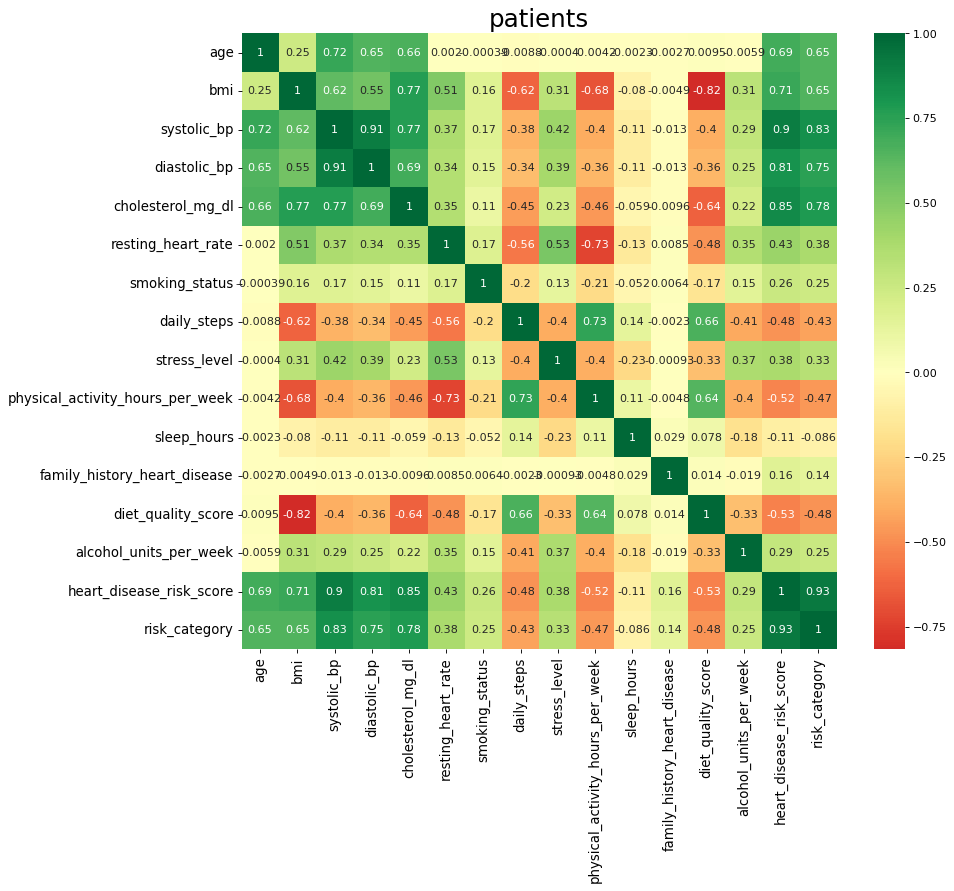

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
heatdf = df
plt.figure(figsize = (12,10), dpi = 80)
sns.heatmap(heatdf.corr(), xticklabels = heatdf.corr().columns, yticklabels = heatdf.corr().columns, cmap = 'RdYlGn', center = 0, annot = True)
plt.title('patients', fontsize = 22)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

In [5]:
x = df.drop(['risk_category'], axis = 1).to_numpy()
y = df['risk_category'].to_numpy()

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

In [8]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.Dense(x_train.shape[1] * 5, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(3, activation='softmax') 
])


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss = 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
                )

early_stopping = EarlyStopping(
                    monitor='val_loss',
                    patience = 20,
                    min_delta = 0.01,
                    verbose = 0,
                    restore_best_weights = True
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 100,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle=False,
        validation_split = 0.1
        )

train_loss, train_acc = model.evaluate(x_train, y_train)
test_loss, test_acc = model.evaluate(x_test, y_test)
print('accuracy:', train_acc, ' \ ', test_acc)

147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9656 - loss: 0.1495 
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9770 - loss: 0.1399 
accuracy: 0.9655615091323853  \  0.9769697189331055


In [16]:
pip install scikit-learn scikeras

In [17]:
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier


n_features = x_train.shape[1]
n_classes = len(np.unique(y_train))

def classification(
    n_features,
    n_classes,
    dropout = 0.3,
#    l1_coef = 0.001
    learning_rate = 1e-3, 
    hidden = 5,
    activation ='relu',
    last_activation='softmax',
    loss_m = 'sparse_categorical_crossentropy'):
        model = keras.Sequential([
            keras.layers.Dense(n_features * hidden, activation=activation, input_shape=(n_features,)),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(n_features, activation =activation, kernel_regularizer='l1'),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(n_classes, activation=last_activation) 
        ])
        model.compile( optimizer = keras.optimizers.Adam(learning_rate = learning_rate),
                loss = loss_m,
                metrics = ['accuracy']
                )
        return model   

In [18]:
classification_model = KerasClassifier(
    model = classification,
    n_features = n_features,
    n_classes = n_classes,
    dropout =  0.3,
    learning_rate = 1e-3,
    activation ='relu',
    last_activation='softmax',
    loss_m = 'sparse_categorical_crossentropy',
    batch_size = 16,
        epochs = 2000,
        verbose = 0,
        callbacks = [EarlyStopping(
                    monitor='val_loss',
                    patience = 20,
                    min_delta = 0.01,
                    verbose = 0,
                    restore_best_weights = True
                    )], 
        shuffle=False,
        validation_split = 0.1
    )
    

In [19]:
pipe = Pipeline([
    ('classification_model', classification_model)
])

In [20]:
pipe.fit(x_train, y_train)

C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

Pipeline(steps=[('classification_model',
                 KerasClassifier(activation='relu', batch_size=16, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000021BC0F2AB10>], dropout=0.3, epochs=2000, last_activation='softmax', learning_rate=0.001, loss_m='sparse_categorical_crossentropy', model=<function classification at 0x0000021BC9179580>, n_classes=3, n_features=15, shuffle=False, validation_split=0.1, verbose=0))])

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

n_features = x_train.shape[1]
n_classes = len(np.unique(y_train))

In [24]:
class NeuralNetworkTrainer(BaseEstimator, TransformerMixin):
    def __init__(n_features = n_features,  n_classes = n_classes, dropout = 0.3,
    #    l1_coef = 0.001
        learning_rate = 1e-3, 
        hidden = 5,
        activation ='relu',
        last_activation='softmax',
        loss_m = 'sparse_categorical_crossentropy'):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None


    def new_model(self):
        model = keras.Sequential([
            keras.layers.Dense(n_features * hidden, activation=activation, input_shape=(n_features,)),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(n_features, activation =activation, kernel_regularizer='l1'),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(n_classes, activation=last_activation) 
        ])
        model.compile( optimizer = keras.optimizers.Adam(learning_rate = learning_rate),
                loss = loss_m,
                metrics = ['accuracy']
                )
        return model

In [25]:
import torch
from torch.utils.data import Dataset, DataLoader

class my_Dataset(Dataset):
    
    def __init__(self, features, labels):

        self.features = torch.as_tensor(features, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.float32)

        self.mean = self.features.mean(dim = 0)
        self.std = self.features.std(dim = 0)
        
        self.normalized_features = (self.features - self.mean) / self.std
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.normalized_features[idx], self.labels[idx]
    
    def get_original(self, idx):
        return self.features[idx], self.labels[idx]

In [26]:
train_dataset = my_Dataset(x_train, y_train)    
test_dataset = my_Dataset(x_test, y_test)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [27]:
import torch.nn as nn

class Regressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, input_size * 5)
        self.act1 = nn.ReLU()
        self.drop = nn.Dropout(0.3)
        self.layer2 = nn.Linear(input_size * 5, input_size)
        self.act2 = nn.ReLU()
        self.last_layer = nn.Linear(input_size, 1)
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.act1(out)
        out = self.drop(out)
        out = self.layer2(out)
        out = self.act2(out)
        out = self.last_layer(out)
        return out     

In [28]:
from sklearn.metrics import r2_score

def train_model(model, train_loader, num_epochs=2000, learning_rate=1e-3,
                weight_decay=1e-4, patience=20, min_delta=0.01):

    device = next(model.parameters()).device
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=weight_decay)

    history = {'train_loss': [], 'train_r2': []}
    best_r2 = -float('inf')
    best_weights = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        all_labels, all_preds = [], []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            if labels.dim() == 1:
                labels = labels.unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            all_labels.append(labels.detach().cpu().numpy())
            all_preds.append(outputs.detach().cpu().numpy())

        # Расчёт метрик за эпоху
        avg_loss = train_loss / len(train_loader)
        y_true = np.concatenate(all_labels, axis=0)
        y_pred = np.concatenate(all_preds, axis=0)
        r2 = r2_score(y_true, y_pred)

        history['train_loss'].append(avg_loss)
        history['train_r2'].append(r2)

        # Ранняя остановка по train_r2
        if r2 > best_r2 + min_delta:
            best_r2 = r2
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if best_weights is not None:
                    model.load_state_dict(best_weights)
                print(f'\nEarly stopping on epoch {epoch}')
                print(f'Train Loss: {avg_loss:.4f}, Train R2: {r2:.4f}')
                break

        # Логирование
        if epoch % 10 == 0:
            print(f'\nEpoch {epoch}/{num_epochs}:')
            print(f'Train Loss: {avg_loss:.4f}, Train R2: {r2:.4f}')

    return model, history

In [29]:
model = Regressor(x.shape[1])

trained_model, history = train_model(
        model = model,
        train_loader = train_loader,
        num_epochs = 2000,
        learning_rate = 1e-3
        )


Epoch 0/2000:
Train Loss: 0.2250, Train R2: 0.6167

Epoch 10/2000:
Train Loss: 0.0628, Train R2: 0.8928

Epoch 20/2000:
Train Loss: 0.0334, Train R2: 0.9429

Epoch 30/2000:
Train Loss: 0.0147, Train R2: 0.9750

Epoch 40/2000:
Train Loss: 0.0103, Train R2: 0.9825

Epoch 50/2000:
Train Loss: 0.0098, Train R2: 0.9832

Early stopping on epoch 51
Train Loss: 0.0091, Train R2: 0.9845


In [30]:
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader):
    
    test_r2 = 0
    all_labels = []
    all_predictions = []
        
    for batch_idx, (inputs, labels) in enumerate(train_loader):
                      
        outputs = model(inputs)

        if labels.dim() == 1:
            labels = labels.unsqueeze(1).float() 
        elif labels.dim() == 2 and labels.dtype != torch.float32:
            labels = labels.float()

        all_labels.append(labels.detach().numpy())
        all_predictions.append(outputs.detach().numpy())

    all_labels_np = np.concatenate(all_labels, axis=0)
    all_predictions_np = np.concatenate(all_predictions, axis=0)
    test_r2 = r2_score(all_labels_np, all_predictions_np)
    
    print(f"r2: {test_r2:.4f}%")
    return test_r2, all_predictions, all_labels

In [36]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # График потерь
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График точности
    axes[1].plot(history['train_r2'], label='Train r2', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('r2')
    axes[1].set_title('Training r2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()

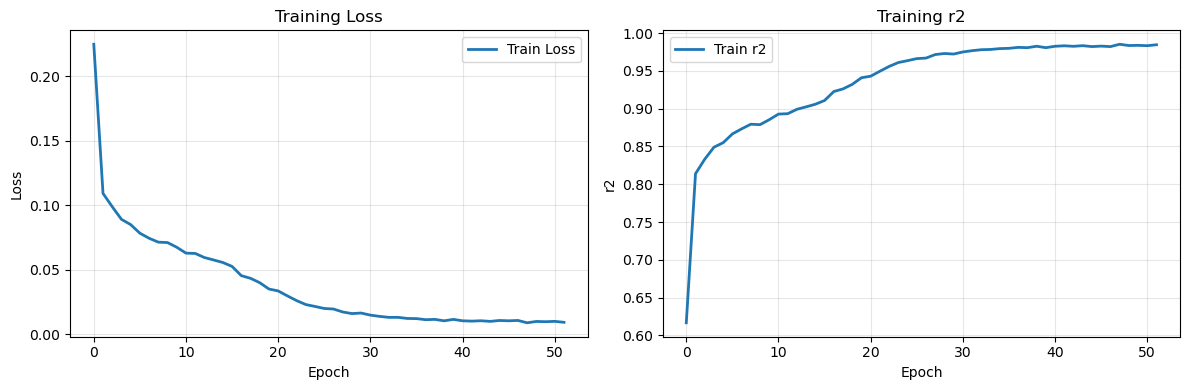

In [37]:
plot_training_history(history)

In [38]:
print("test results")
test_accuracy, test_predictions, test_labels = evaluate_model(trained_model, test_loader)
print("train results")
train_accuracy, train_predictions, train_labels = evaluate_model(trained_model, train_loader)

test results
r2: 0.9854%
train results
r2: 0.9850%
